# Markov-Mint 🎲
### Can a Markov chain really 'win every single trade' on Polymarket?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Win--every--trade: Busted](https://img.shields.io/badge/Win--every--trade-Busted-8b949e?style=flat-square)

A viral thread promises something irresistible: model a prediction-market price as a **Markov chain**, simulate thousands of resolutions, calibrate, size with Kelly, and **win every single trade** — with real, runnable code. Here's the catch it never checks: what does the machine print on a market that is *already priced correctly*, where by definition there is no edge to find? If it 'finds' one there, it's finding noise. So we build markets whose true answer we know, and feed the thread's own code to them.

> 📓 **This is the plain-language layer.** Want the statistics, the microstructure and the capacity maths? That's the companion notebook, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** An educational, reproducible research tool: every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (markov_mint/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from markov_mint import data, robustness
from markov_mint.markov import MarkovMintSystem

# Small & fast: a martingale NULL (price = fair posterior, no edge exists) and a planted
# favorite-longshot WEDGE (longshots rich, favorites cheap — a real edge of known size and
# sign). Headline numbers (2,000 markets, the article's 10,000 Monte-Carlo paths) are in
# ../docs/results.md via examples/verify.py; here we trim the path count for speed.
SYS = MarkovMintSystem(n_sims=1500)
null = data.efficient_markets(n_markets=500, seed=0)
wedge = data.biased_markets(n_markets=500, seed=1)
print(f"{len(null)} fair markets, {len(wedge)} with a planted wedge")
print(f"sanity: mean outcome {np.mean([m.outcome for m in null]):.3f} == mean price "
      f"{np.mean([m.current_price for m in null]):.3f}  (a fair, calibrated market)")


500 fair markets, 500 with a planted wedge
sanity: mean outcome 0.550 == mean price 0.546  (a fair, calibrated market)


## 1 · The Claim

The pipeline has five steps: (1) bucket the price history into 10 states and count how it moves between them (the **transition matrix**); (2) **Monte-Carlo** thousands of paths to expiry; (3) **calibrate** against a longshot table; (4) size with **quarter-Kelly**; (5) execute as a **maker**. Let's look at one of our 'fair' markets — a price that wanders honestly toward its outcome.

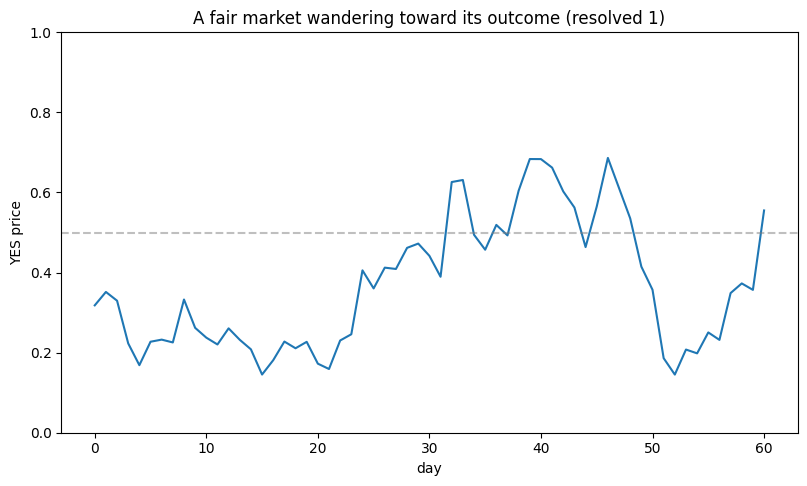

This price is the exact fair probability — there is nothing to arbitrage.


In [2]:
m = null[3]
plt.plot(m.prices, lw=1.5)
plt.axhline(0.5, color='grey', ls='--', alpha=0.5)
plt.title(f'A fair market wandering toward its outcome (resolved {m.outcome})')
plt.xlabel('day'); plt.ylabel('YES price'); plt.ylim(0, 1); plt.show()
print('This price is the exact fair probability — there is nothing to arbitrage.')

## 2 · So What?

If past prices alone could front-run a resolution, it would be a money printer — and a crack in one of the most-studied ideas in finance: that a correctly priced contract moves *unpredictably* from its own history. Prediction markets make the test clean: every contract resolves, so we can score every bet against a real yes/no answer.

## 3 · How We'd Know

We announced the falsification before running it: on a **fair** market the machine must capture **no edge** (it can't beat a price that's already right). If it bets and wins only ~half the time, and a Kelly bankroll shrinks, the framework is trading noise. We don't *assume* the market is fair — we build it as a genuine probability and check it's calibrated (mean outcome == mean price, printed above).

In [3]:
df = robustness.analyze_markets(null, SYS, seed=0)
head = robustness.headline_test(df)
print(f"machine edge per trade : {head['machine_edge_pp']:+.2f} pp  (t = {head['machine_t']:+.2f})")
print(f"best possible (oracle) : {head['oracle_edge_pp']:+.2f} pp  -> nothing to find on a fair market")
print(f"takes a position on    : {head['n_active']}/{head['n_total']} markets")

machine edge per trade : +0.33 pp  (t = +0.21)
best possible (oracle) : +0.00 pp  -> nothing to find on a fair market
takes a position on    : 289/500 markets


## 4 · The Teardown

The 'edge' the chain reports is **noise**, and you can see it melt as you give the model *more* history (a real signal would not). Below: the spread of the raw Monte-Carlo edge shrinks toward zero as the price history grows from 20 to 250 days.

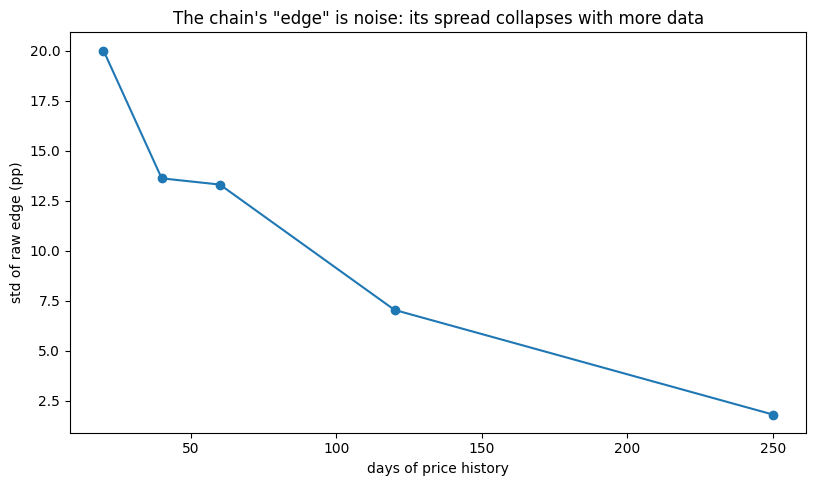

,mean_raw_edge_pp,std_raw_edge_pp,frac_positive
hist_len,,,
20,0.6700,20.0010,0.5430
40,0.4500,13.6100,0.4870
60,0.2140,13.2990,0.5230
120,0.2860,7.0320,0.5000
250,0.0690,1.8020,0.5070


In [4]:
hist = robustness.edge_vs_history(hist_lens=(20, 40, 60, 120, 250),
                                  n_markets=300, seed=0, system=SYS)
plt.plot(hist.index, hist['std_raw_edge_pp'], 'o-')
plt.title('The chain\'s "edge" is noise: its spread collapses with more data')
plt.xlabel('days of price history'); plt.ylabel('std of raw edge (pp)'); plt.show()
hist.round(3)

And when you size those coin-flip bets with Kelly and score them against the **true** outcomes, the bankroll doesn't grow — it's destroyed. The win rate is ~50%, not the promised 100%.

In [5]:
pnl = robustness.pnl_sim(df, spread=0.02, seed=0)
print(f"win rate           : {pnl['win_rate']:.1%}   (the thread promised 100%)")
print(f"terminal bankroll  : {pnl['terminal_bankroll']:.4f}x  net of the 1c entry half-spread")
sweep = robustness.cost_sweep(df, spreads=(0.0, 0.01, 0.02, 0.04, 0.08), seed=0)
sweep[['mean_ret', 'win_rate']].round(3)

win rate           : 49.5%   (the thread promised 100%)
terminal bankroll  : 0.3650x  net of the 1c entry half-spread


,mean_ret,win_rate
spread,,
0.0000,0.0030,0.4950
0.0100,-0.1320,0.4950
0.0200,-0.1990,0.4950
0.0400,-0.2690,0.4950
0.0800,-0.3330,0.4740


## 5 · The Verdict

On the full **2,000-market** run (see [`docs/results.md`](../docs/results.md)):

- The machine's directional edge is **−0.45 pp** (statistically zero) — the best any method could do on a fair market is **0**. → **Signal: NONE**
- Kelly-sized, the bankroll falls to **0.0003×** net of the 1¢ entry half-spread — and to **0.0017× even at zero cost**: compounding coin-flip bets is pure variance drag. The thread's calibration table caps at 0.958, so it **reflexively shorts every strong favorite** — zero expected value on fair odds, but lottery-ticket variance a Kelly book never gets paid for. → **Tradability: MIRAGE**
- Win rate **51.5%**. → **'Win every trade': BUSTED**

## 6 · Could You Trade It?

We replant the one real effect the thread gestures at — the favorite-longshot bias (longshots priced *rich*, favorites *cheap*) — and ask what each player recovers. The machine does detect it **gross** (+1.83 pp per trade, via its borrowed calibration table, not the chain) and still loses **−22% per trade net**, because it trades cost-blind and the ~1.7¢ wedge is thinner than the 1¢ toll on most of its trades. Even an oracle that **knows the true probabilities** only nets **+2.3% per trade** — and only by refusing every market where the toll dominates the wedge. Perfect information beats the spread only by trading selectively; the pipeline has neither the information nor the selectivity.

## 7 · Going Further

The deep-dive notebook (`02_for_the_quants`) carries the HAC inference, the Markov-ablation, the calibration-ceiling bug, and the planted-edge recovery. The clean next tests: a real Polymarket tape, and a *debugged* pipeline (to show it still reduces to 'bet the longshot bias' and dies to the spread). **Fork it, break it, PR a better test.**